## Problem Statement

### Context

AllLife Bank is a mid-sized, fast-growing US-based financial institution that offers a range of retail banking services, including savings and checking accounts, fixed deposits, and personal loans. The bank’s business model is centered on building long-term customer relationships, expanding its retail footprint, and growing its loan portfolio to drive sustainable profitability through interest income.

It currently relies on a large base of liability customers (depositors) but faces a significant under-representation of asset customers (borrowers). To drive profitability through interest income, the bank must aggressively expand its loan portfolio by converting existing depositors into personal loan customers.

Last year’s pilot campaign achieved a 9% conversion rate, validating the potential of this strategy. However, to optimize marketing spend and improve efficiency, the retail marketing department requires a more data-driven approach. Enhancing the success ratio of these campaigns is critical for sustainable growth and maximizing customer lifetime value.

### Objective

The objective is to develop a predictive classification model that identifies patterns and key factors driving personal loan adoption among existing liability customers. By uncovering the demographic and behavioral drivers of loan conversion, the goal is to enable targeted segmentation and more precise marketing interventions that improve campaign conversion rates, optimize marketing spend, and enhance overall profitability through higher-quality loan portfolio growth.

### Data Dictionary

* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [29]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 sklearn-pandas==2.2.0 -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

# Libraries for scaling numerical features
from sklearn.preprocessing import StandardScaler

# to perform k-means clustering
from sklearn.cluster import KMeans

# to perform silhouette analysis
from sklearn.metrics import silhouette_score

# to perform t-SNE
from sklearn.manifold import TSNE

# to define a common seed value to be used throughout
RS=0

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [3]:
data = pd.read_csv('Loan_Modelling.csv')

## Data Overview

* Observations
* Sanity checks

In [4]:
data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [5]:
data.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


In [6]:
data.shape

(5000, 14)

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [9]:
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


In [10]:
data.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis.

EDA is a critical step in any data project used to investigate and understand the data before model construction.

The following questions serve as a starting point to help you approach the analysis and generate initial insights:

**Questions**:
1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their education?
5. How does a customer's interest in purchasing a loan vary with their age?

**[IMPORTANT]** Beyond the Basics: Please note that these are guiding questions only. To receive full points for this rubric section, you are expected to perform a thorough analysis that goes beyond these specific questions to uncover deeper trends and relationships within the data.

<Axes: xlabel='ID', ylabel='Count'>

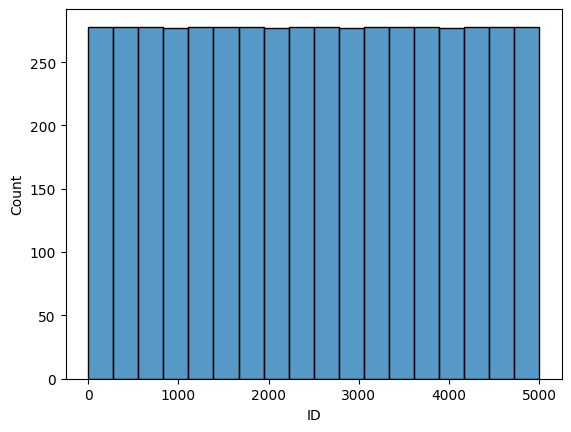

In [11]:
sns.histplot(data=data, x='ID')

ID is uniformaly distributed and it goes from 1 to 5000. ID is a redundant field for this analysis so it can be dropped.

In [12]:
data.drop('ID', axis=1, inplace=True)

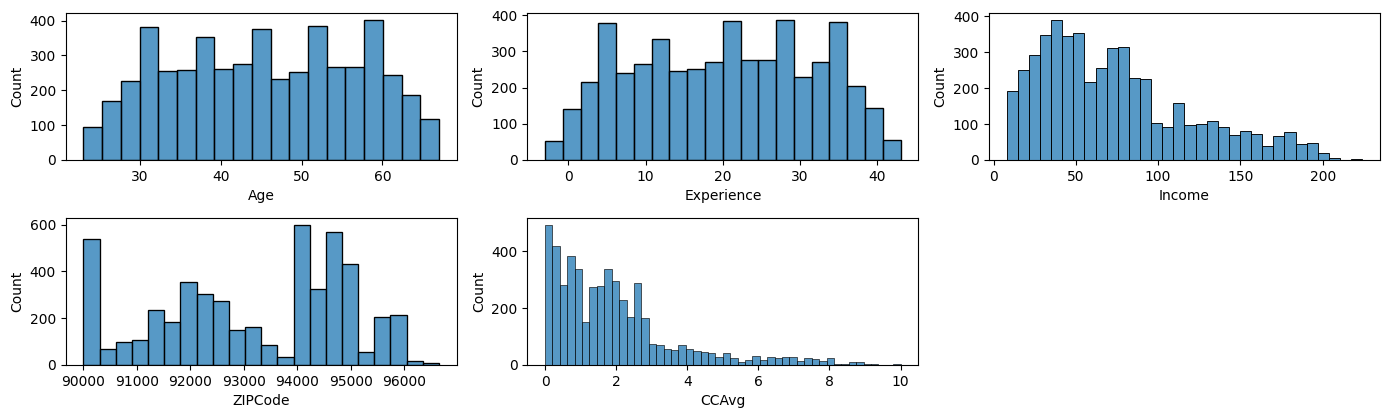

In [13]:
# defining the figure size
plt.figure(figsize=(14, 10))

# plotting the histogram for each numerical feature
for i, feature in enumerate(['Age','Experience','Income','ZIPCode', 'CCAvg']):
    plt.subplot(5, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots

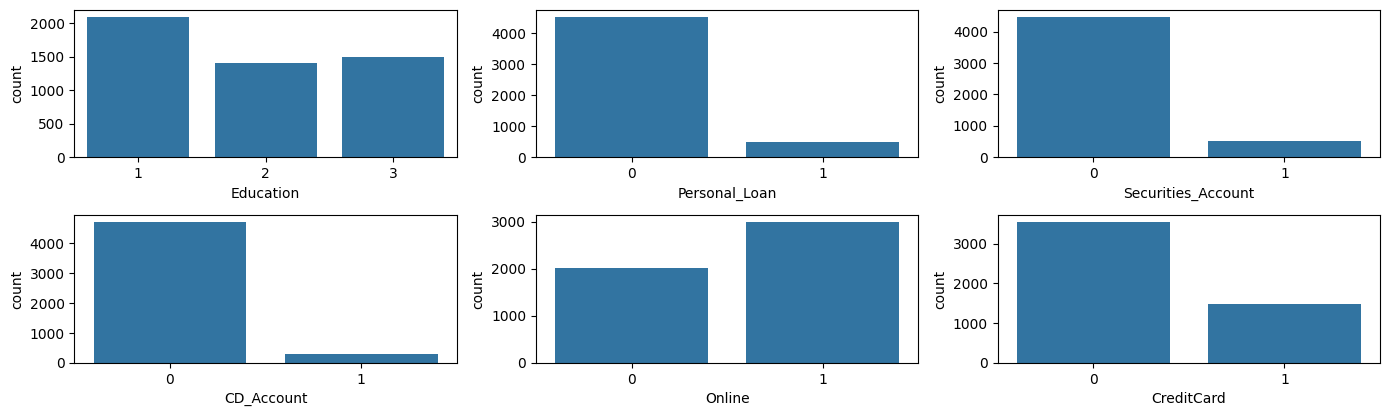

In [14]:
# defining the figure size
plt.figure(figsize=(14, 10))

# plotting the histogram for each numerical feature
for i, feature in enumerate(['Education', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard']):
    plt.subplot(5, 3, i+1)    # assign a subplot in the main plot
    sns.countplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots

In [15]:
data.columns

Index(['Age', 'Experience', 'Income', 'ZIPCode', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard'],
      dtype='object')

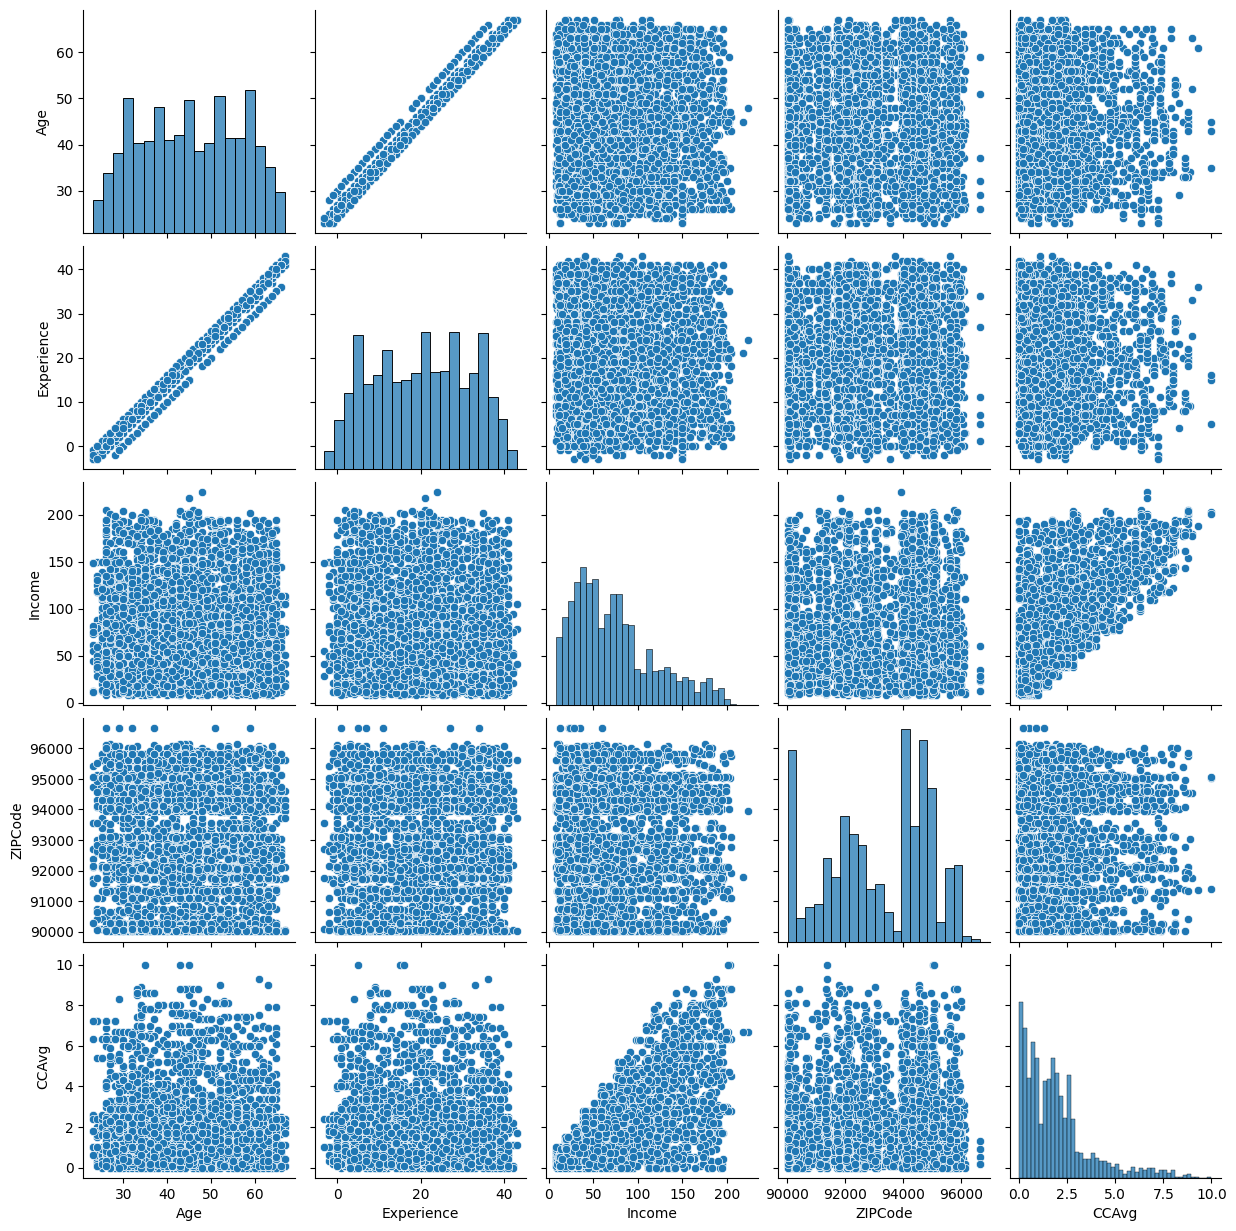

In [16]:
sns.pairplot(data[['Age','Experience','Income','ZIPCode', 'CCAvg']])

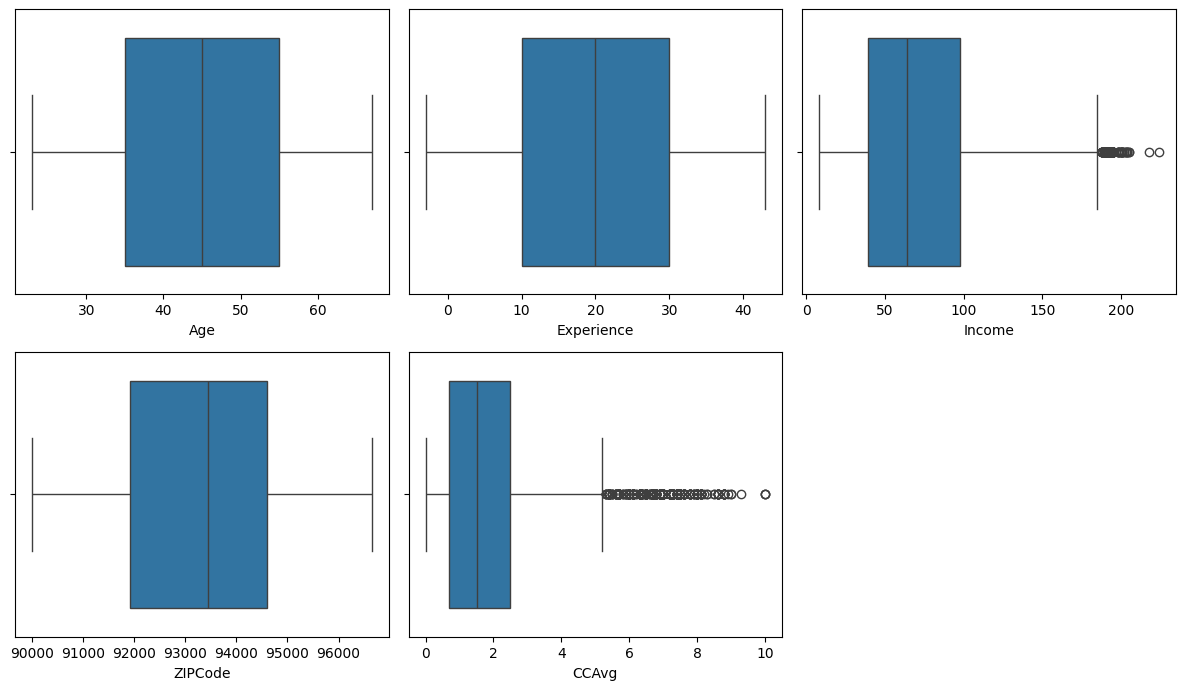

In [17]:
# defining the figure size
plt.figure(figsize=(12, 10))

# plotting the boxplot for each numerical feature
for i, feature in enumerate(['Age','Experience','Income','ZIPCode', 'CCAvg']):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.boxplot(data=data, x=feature)    # plot the boxplot

plt.tight_layout();   # to add spacing between plots

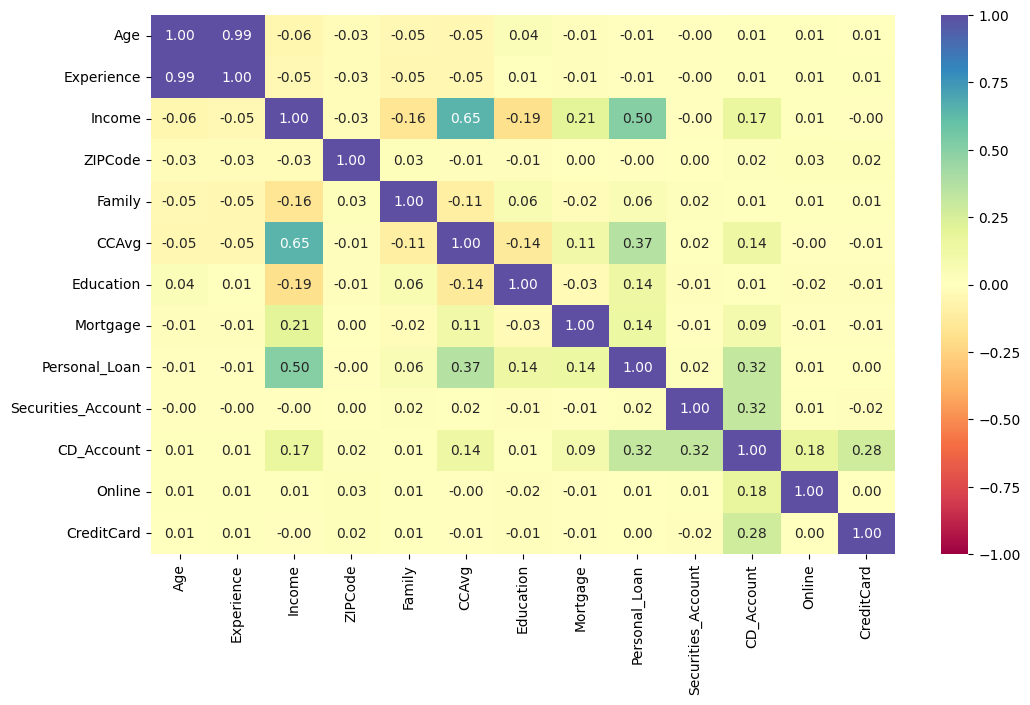

In [18]:
# defining the size of the plot
plt.figure(figsize=(12, 7))
# plotting the heatmap for correlation
sns.heatmap(
    data.corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
);

Since the target variable is 'Personal_Loan', we should study the variables that predict it best. From the heatmap, five variables have a medium to high correlation with Personal_Loan.

<Axes: xlabel='Income', ylabel='CCAvg'>

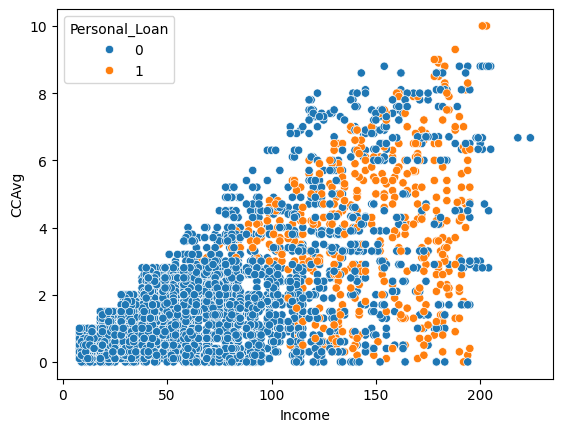

In [19]:
sns.scatterplot(data=data, x='Income', y='CCAvg', hue='Personal_Loan')
#

<Axes: xlabel='Income', ylabel='Mortgage'>

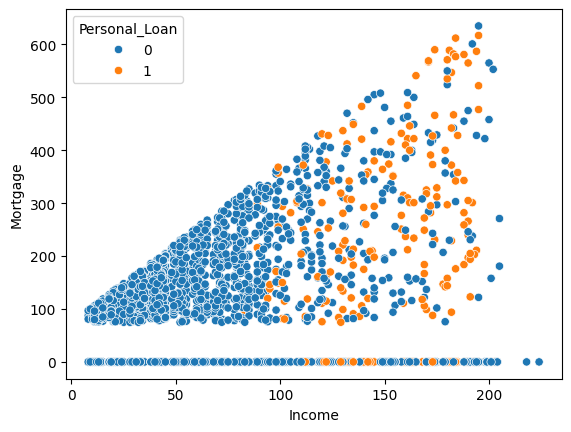

In [20]:
sns.scatterplot(data=data, x='Income', y='Mortgage', hue='Personal_Loan')

<Axes: xlabel='Education', ylabel='count'>

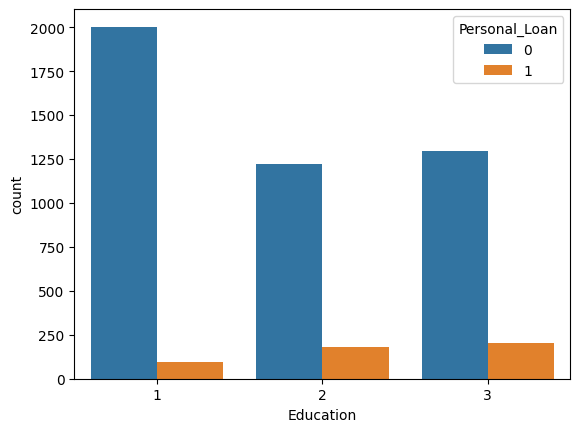

In [30]:
sns.countplot(data=data, x='Education', hue='Personal_Loan')
#

<Axes: xlabel='CD_Account', ylabel='count'>

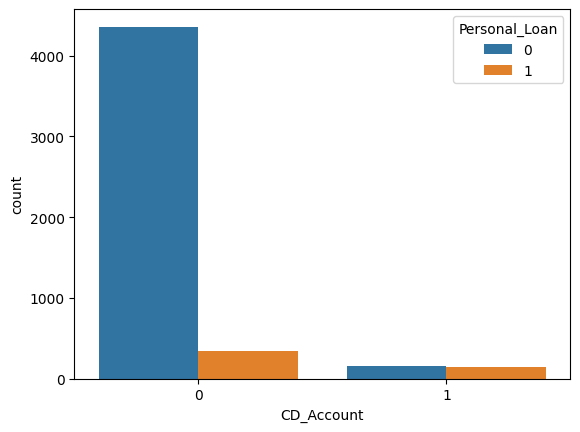

In [31]:
sns.countplot(data=data, x='CD_Account', hue='Personal_Loan')

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

In [32]:
X = data.drop(["Personal_Loan"], axis=1)
Y = data["Personal_Loan"]

X = X.astype(float)

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1
)

In [33]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3500, 12)
Shape of test set :  (1500, 12)
Percentage of classes in training set:
Personal_Loan
0    0.905429
1    0.094571
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.900667
1    0.099333
Name: proportion, dtype: float64


Creating a scaled dataset to clsuter the data.

In [34]:
#Initialise the scaler object
scaler = StandardScaler()

# Fit the scaler to the numerical columns, transform them (i.e., execute the scaling), and create a new dataframe with scaled data
scaled_data = pd.DataFrame(scaler.fit_transform(data))

# Display the scaled data
scaled_data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-1.774417,-1.666078,-0.538229,-1.172217,1.397414,-0.193385,-1.049078,-0.555524,-0.325875,2.928915,-0.25354,-1.216618,-0.645314
1,-0.029524,-0.096330,-0.864109,-1.750863,0.525991,-0.250611,-1.049078,-0.555524,-0.325875,2.928915,-0.25354,-1.216618,-0.645314
2,-0.552992,-0.445163,-1.363793,0.881465,-1.216855,-0.536736,-1.049078,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618,-0.645314
3,-0.901970,-0.968413,0.569765,0.535869,-1.216855,0.436091,0.141703,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618,-0.645314
4,-0.901970,-1.055621,-0.625130,-1.045461,1.397414,-0.536736,0.141703,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618,1.549632


In [35]:
scaled_data.describe().T

,count,mean,std,min,25%,50%,75%,max
0,5000.0,-2.131628e-18,1.0001,-1.948906,-0.901970,-0.029524,0.842923,1.889859
1,5000.0,-1.179501e-16,1.0001,-2.014911,-0.881204,-0.009122,0.862960,1.996667
2,5000.0,1.449507e-16,1.0001,-1.428969,-0.755483,-0.212348,0.526315,3.263712
3,5000.0,1.260148e-15,1.0001,-1.798610,-0.715212,0.152189,0.817803,1.979074
4,5000.0,1.001865e-16,1.0001,-1.216855,-1.216855,-0.345432,0.525991,1.397414
5,5000.0,-6.394885e-17,1.0001,-1.108987,-0.708412,-0.250611,0.321641,4.613525
6,5000.0,2.557954e-17,1.0001,-1.049078,-1.049078,0.141703,1.332484,1.332484
7,5000.0,-5.613288e-17,1.0001,-0.555524,-0.555524,-0.555524,0.437558,5.688108
8,5000.0,-4.973799e-17,1.0001,-0.325875,-0.325875,-0.325875,-0.325875,3.068659
9,5000.0,-2.273737e-17,1.0001,-0.341423,-0.341423,-0.341423,-0.341423,2.928915


In [36]:
scaled_data.columns = data.columns
scaled_data.head()

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,-1.774417,-1.666078,-0.538229,-1.172217,1.397414,-0.193385,-1.049078,-0.555524,-0.325875,2.928915,-0.25354,-1.216618,-0.645314
1,-0.029524,-0.096330,-0.864109,-1.750863,0.525991,-0.250611,-1.049078,-0.555524,-0.325875,2.928915,-0.25354,-1.216618,-0.645314
2,-0.552992,-0.445163,-1.363793,0.881465,-1.216855,-0.536736,-1.049078,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618,-0.645314
3,-0.901970,-0.968413,0.569765,0.535869,-1.216855,0.436091,0.141703,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618,-0.645314
4,-0.901970,-1.055621,-0.625130,-1.045461,1.397414,-0.536736,0.141703,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618,1.549632


In [37]:
scaled_data_x = scaled_data.drop(columns='Personal_Loan')
scaled_data_y = scaled_data['Personal_Loan']

## Model Building

### Model Evaluation Criterion

*


### Model Building

In [38]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [39]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [40]:
model0 = DecisionTreeClassifier(random_state=1)
model0.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

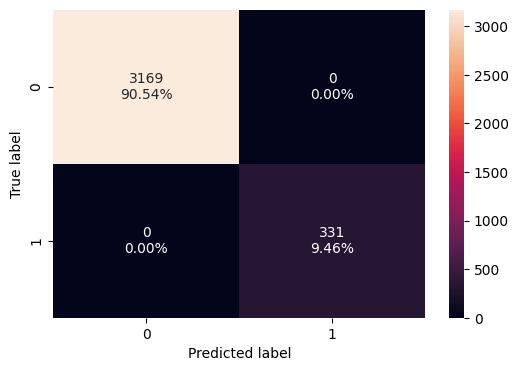

In [41]:
confusion_matrix_sklearn(model0, X_train, y_train)

In [42]:
model_performance_classification_sklearn(model0, X_train, y_train)

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


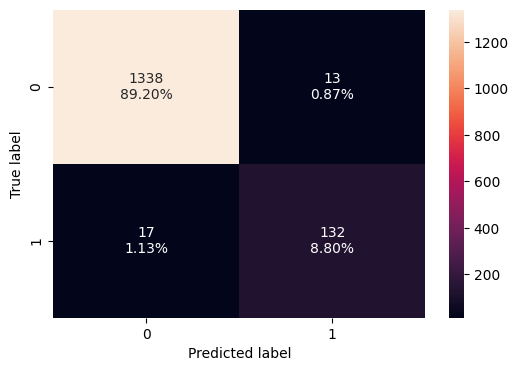

In [43]:
confusion_matrix_sklearn(model0, X_test, y_test)

In [44]:
model_performance_classification_sklearn(model0, X_test, y_test)

,Accuracy,Recall,Precision,F1
0,0.98,0.885906,0.910345,0.897959


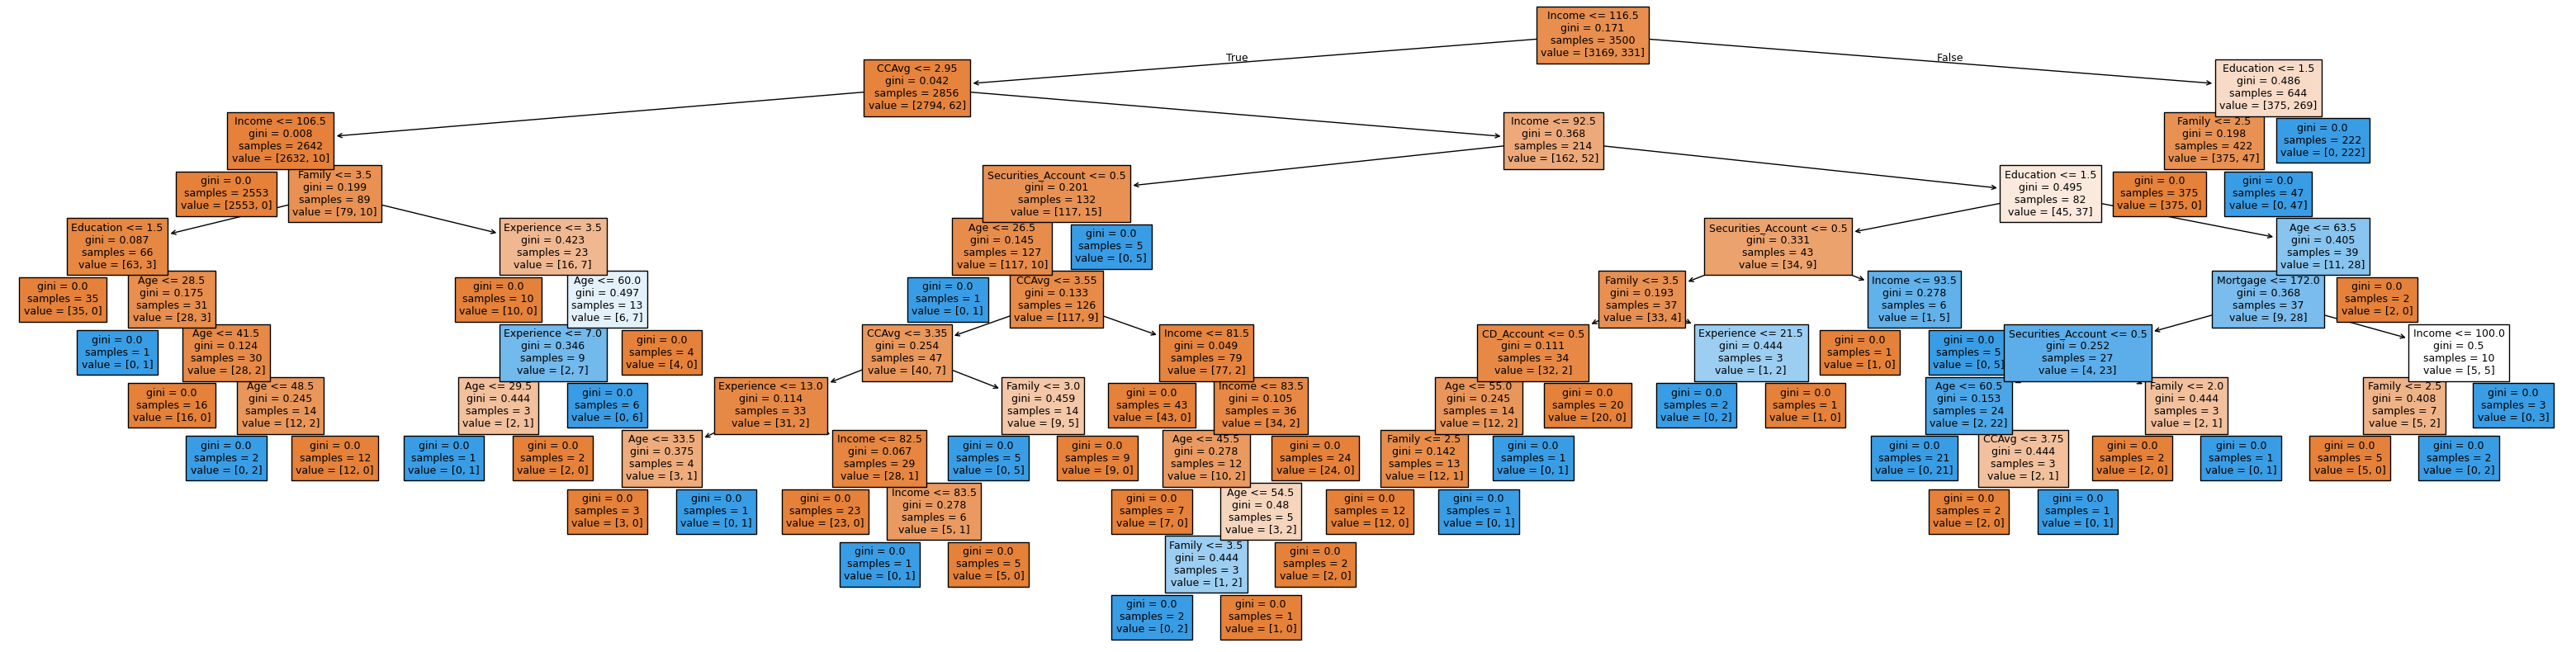

In [45]:
plt.figure(figsize=(40, 10))
out = tree.plot_tree(
    model0,
    feature_names=data.columns,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

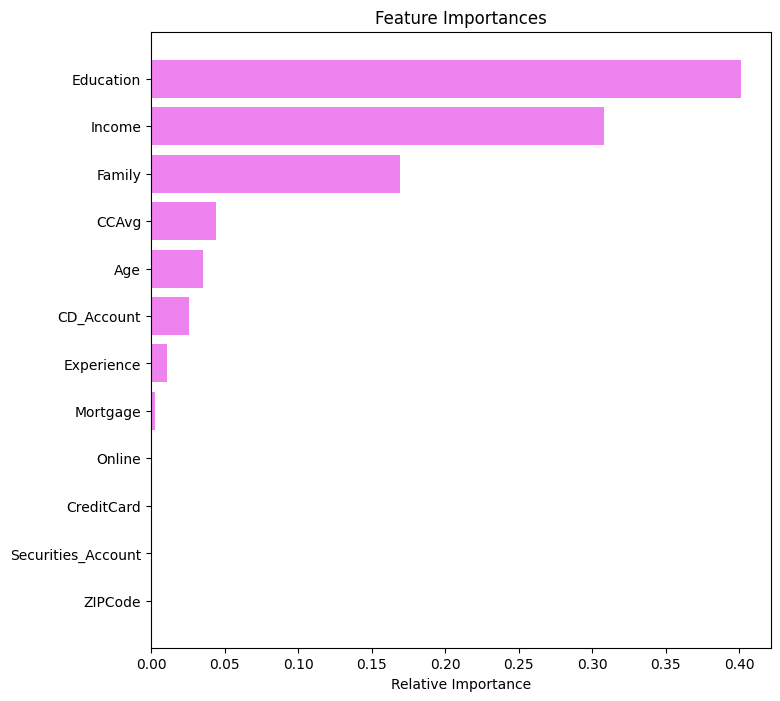

In [46]:
feature_names = list(X_train.columns)
importances = model0.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Pre-Pruning

In [47]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=42
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(y_train, y_train_pred)
            test_recall_score = recall_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

Best parameters found:
Max depth: 2
Max leaf nodes: 50
Min samples split: 10
Best test recall score: 1.0


In [48]:
# Initialize the tree with the current set of parameters
model1 = DecisionTreeClassifier(
    max_depth=2,
    max_leaf_nodes=50,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

# Fit the model to the training data
model1.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=2, max_leaf_nodes=50,
                       min_samples_split=10, random_state=42)

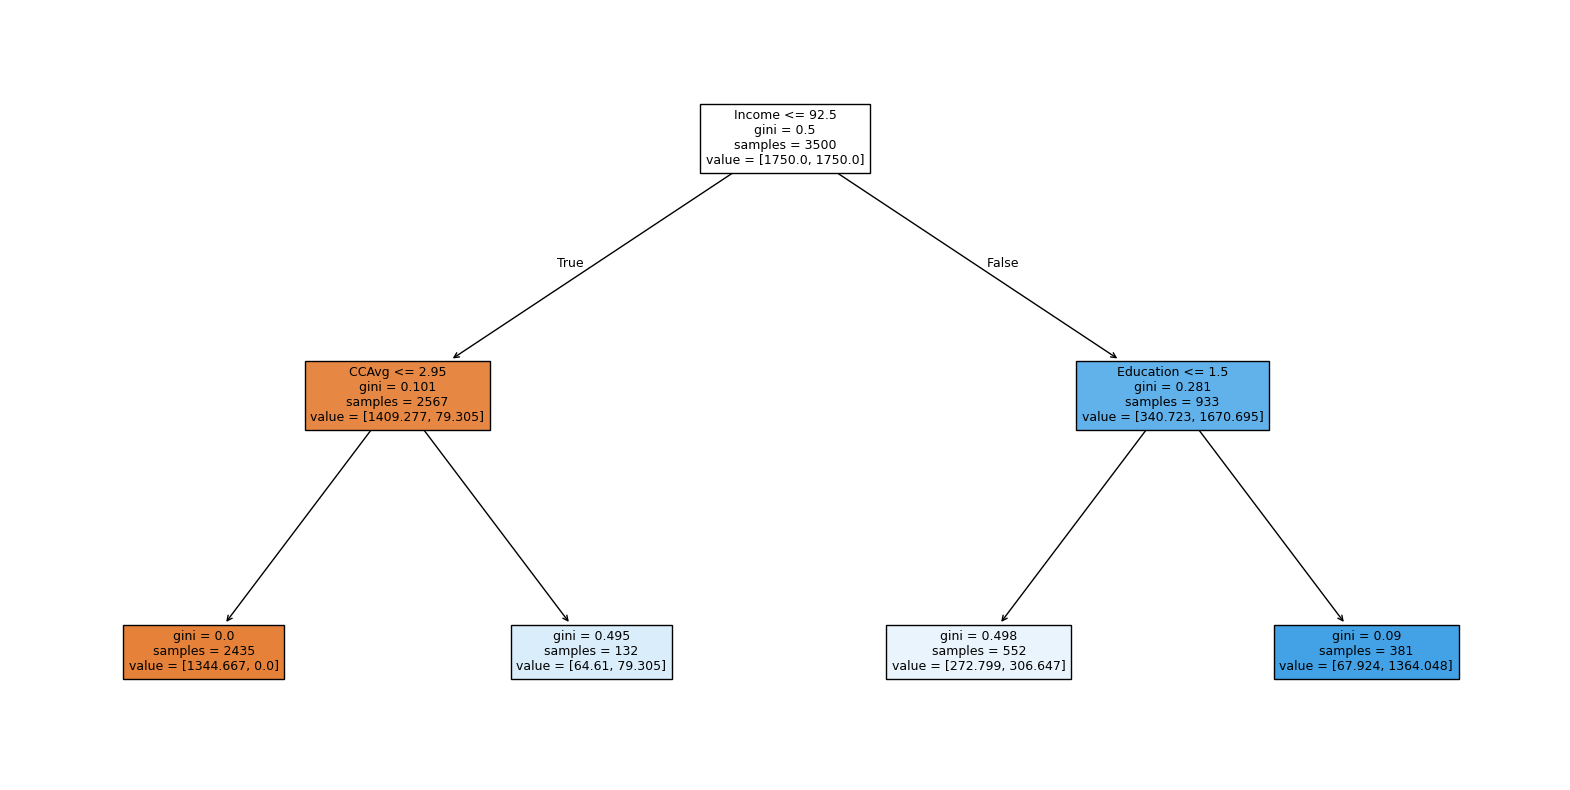

In [49]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    model1,
    feature_names=data.columns,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

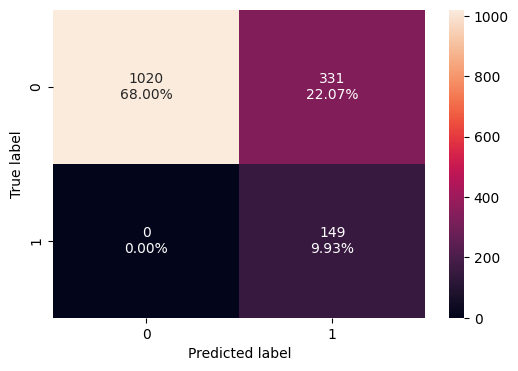

In [50]:
confusion_matrix_sklearn(model1, X_test, y_test)

In [51]:
model_performance_classification_sklearn(model1, X_test, y_test)

,Accuracy,Recall,Precision,F1
0,0.779333,1.0,0.310417,0.473768


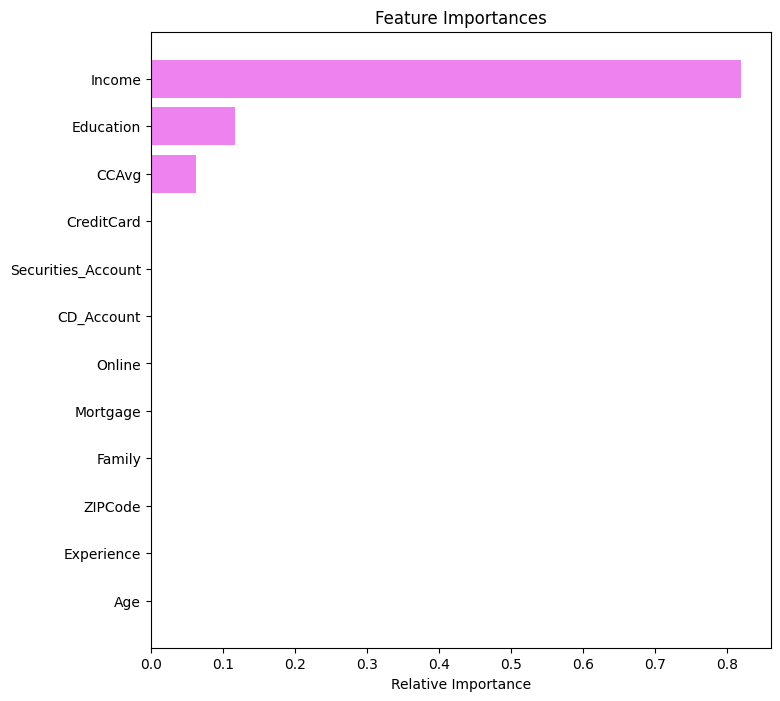

In [52]:
feature_names = list(X_train.columns)
importances = model1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Post Pruning

In [53]:
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [54]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,-7.194433e-15
1,4.729571e-19,-7.193960e-15
2,5.255079e-19,-7.193434e-15
3,1.051016e-18,-7.192383e-15
4,8.338059e-18,-7.184045e-15
5,1.257806e-17,-7.171467e-15
6,1.524700e-04,3.049400e-04
7,1.537634e-04,6.124667e-04
8,1.561475e-04,9.247618e-04
9,1.568682e-04,1.238498e-03


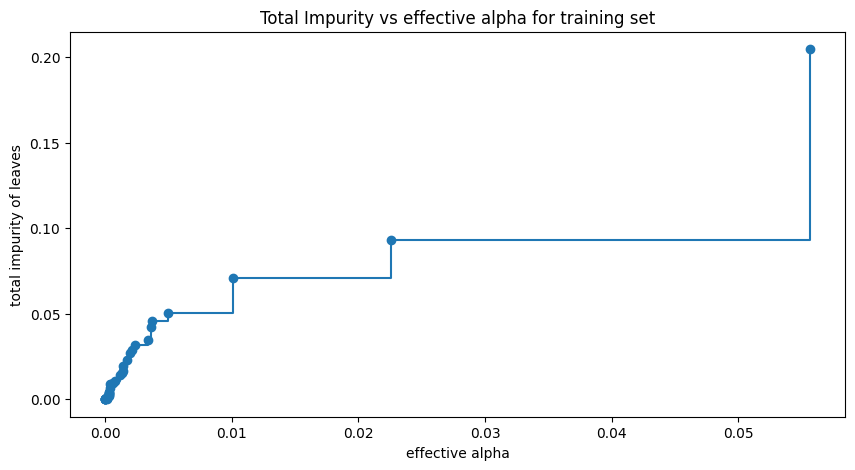

In [55]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [56]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.29537927599923186


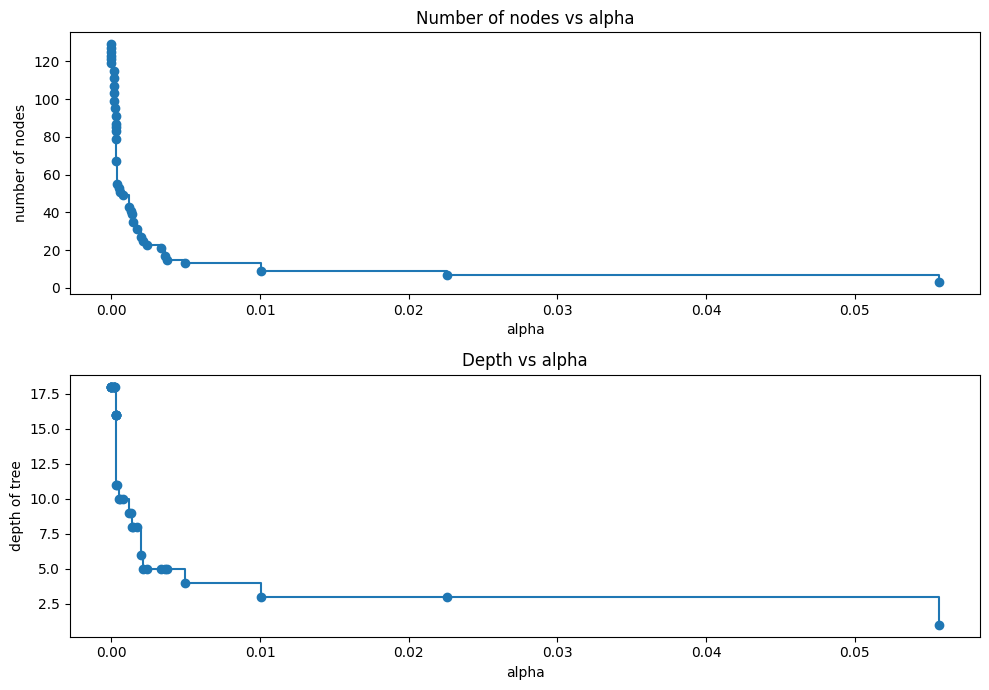

In [57]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [58]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [59]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

In [60]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

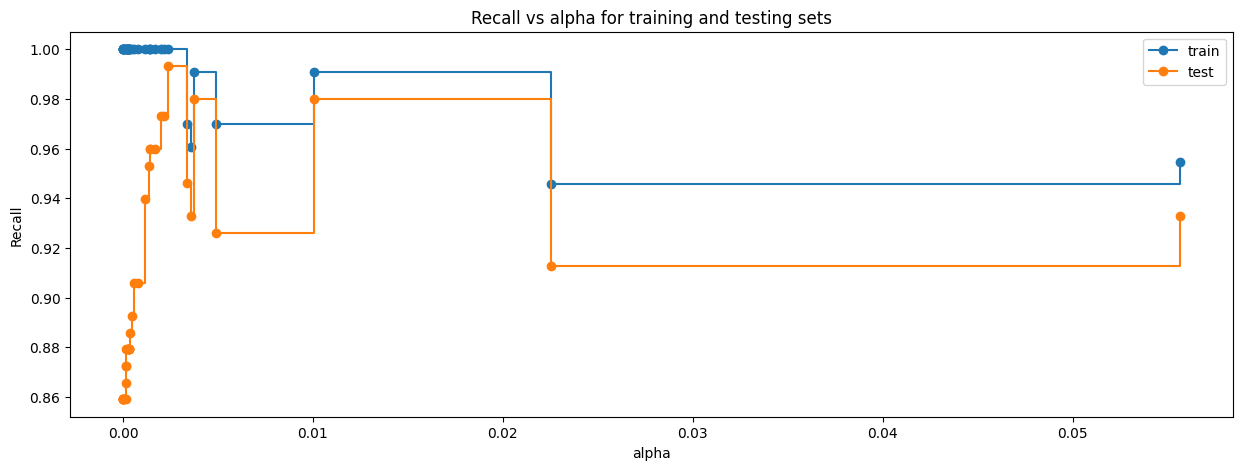

In [61]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [62]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.002375808619774645),
                       class_weight='balanced', random_state=1)


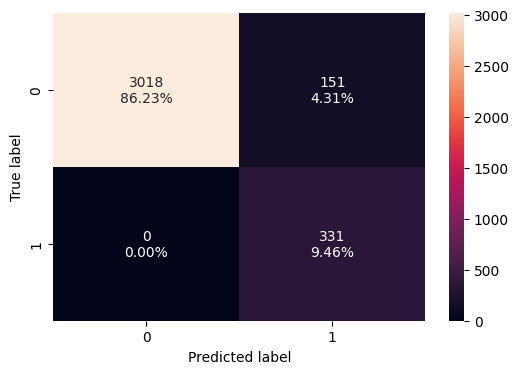

In [63]:
model2 = best_model
confusion_matrix_sklearn(model2, X_train, y_train)

In [64]:
decision_tree_post_perf_train = model_performance_classification_sklearn(
    model2, X_train, y_train
)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,0.956857,1.0,0.686722,0.814268


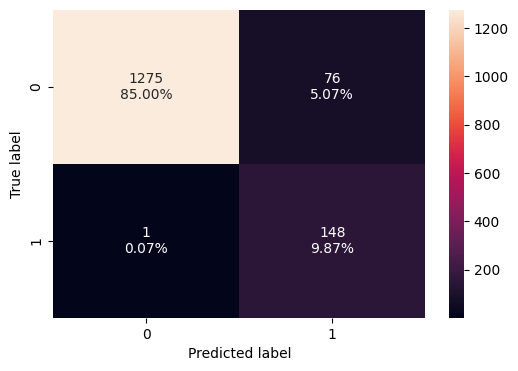

In [65]:
confusion_matrix_sklearn(model2, X_test, y_test)

In [67]:
decision_tree_post_test = model_performance_classification_sklearn(
    model2, X_test, y_test
)
decision_tree_post_test

,Accuracy,Recall,Precision,F1
0,0.948667,0.993289,0.660714,0.793566


Using Clustering to Segment the Customers

In [ ]:
# Initiating the t-SNE object
# n_components=2 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one processor core for parallel computation, which speeds up the process
tsne = TSNE(n_components=2, n_jobs=-2, random_state=RS, perplexity=100)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the t-SNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(scaled_data_x)

# Creating a DataFrame from the reduced data
tsne_2d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2"])) # This DataFrame will have two columns corresponding to the two reduced dimensions

In [ ]:
# Assigning cluster labels to the tsne_2d_data DataFrame
tsne_2d_data['Clusters'] = data['Personal_Loan']
tsne_2d_data.head()

,Feature 1,Feature 2,Clusters
0,-29.332560,29.079718,0
1,-28.530338,31.860273,0
2,-17.621660,1.043796,0
3,-16.727259,5.001462,0
4,-4.963349,20.285385,0


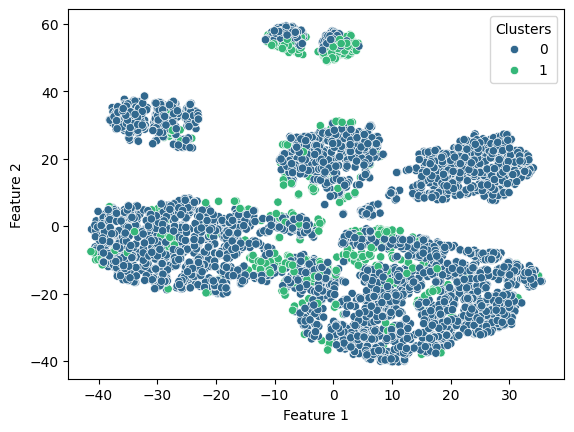

In [ ]:
sns.scatterplot(tsne_2d_data, x='Feature 1', y='Feature 2', hue='Clusters', palette='viridis');

## Model Performance Improvement

## Model Performance Comparison and Final Model Selection

## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?

___